## 제품 유형 1 - 통계 => 이상치 제거하지 않았던 ML용 데이터로 실행해봄
- 정규성 검정
    - Shapiro-Wilk 검정
    - Q-Q Plot
- 등분산성 검정
    - Levene 검정
- 스피어만 상관계수 히트맵

In [1]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 분석/통계
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# matplotlib 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (12, 6)

# seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


---
---
### 1. 데이터 로드

In [2]:
# 1. 전처리가 완료된 Process, Sensor, Defects 관련 데이터 로드
df_process_2 = pd.read_csv('data/for_통계_process_data_product-2.csv')
df_sensor_2 = pd.read_csv('data/for_통계_sensor_data_product-2.csv')
df_defects_2 = pd.read_csv('data/for_통계_defects_data_product-2.csv')
df_original_2 = pd.read_csv('data/for_통계_overall_data_product-2.csv')

In [3]:
# 2. 데이터 크기 확인
print(f"제품 1의 전체 데이터 크기: {df_original_2.shape}")
print(f"제품 1의 전체 데이터 컬럼: {df_original_2.columns}")

print(f"제품 1의 process 관련 데이터 크기: {df_process_2.shape}")
print(f"제품 1의 process 관련 데이터 컬럼: {df_process_2.columns}")

print(f"제품 1의 sensor 관련 데이터 크기: {df_sensor_2.shape}")
print(f"제품 1의 sensor 관련 데이터 컬럼: {df_sensor_2.columns}")

print(f"제품 1의 defects 관련 데이터 크기: {df_defects_2.shape}")
print(f"제품 1의 defects 관련 데이터 컬럼: {df_defects_2.columns}")




제품 1의 전체 데이터 크기: (3328, 24)
제품 1의 전체 데이터 컬럼: Index(['shot_key', 'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
       'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
       'clamping_force', 'cycle_time', 'pressure_rise_time',
       'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time',
       'melting_furnace_temp', 'air_pressure', 'coolant_temp',
       'coolant_pressure', 'factory_temp', 'factory_humidity',
       'surface_defect', 'structural_defect', 'contamination_defect'],
      dtype='object')
제품 1의 process 관련 데이터 크기: (3328, 15)
제품 1의 process 관련 데이터 컬럼: Index(['shot_key', 'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
       'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
       'clamping_force', 'cycle_time', 'pressure_rise_time',
       'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time'],
      dtype='object')
제품 1의 sensor 관련 데이터 크기: (3328, 6)
제품 1의 sensor 관련 데이터 컬럼: Index(['melting_furnace_temp', 'ai

In [6]:
# 3. 불량 유무로 불량 컬럼 통일 -> is_defect 컬럼 생성
# 행을 기준으로 1이 존재하면 불량으로 표현

defect_cols = ['surface_defect', 'structural_defect', 'contamination_defect']

# 불량 데이터프레임
df_defects_2['is_defect'] = df_defects_2[defect_cols].max(axis=1)
# is_defect로 통합 완료 -> 개별 불량 유형 컬럼 제거
df_defects_2_1 = df_defects_2.drop(columns=defect_cols)

# 전체 데이터프레임
df_original_2['is_defect'] = df_original_2[defect_cols].max(axis=1)
# is_defect로 통합 완료 -> 개별 불량 유형 컬럼 제거
df_original_2_1 = df_original_2.drop(columns=defect_cols)


display(df_defects_2_1.head(5))
df_original_2_1.head(5)

,is_defect
0,0
1,0
2,0
3,0
4,0


,shot_key,velocity_1,velocity_2,velocity_3,high_velocity,cylinder_pressure,rapid_rise_time,biscuit_thickness,clamping_force,cycle_time,pressure_rise_time,casting_pressure,spray_time,spray_1_time,spray_2_time,melting_furnace_temp,air_pressure,coolant_temp,coolant_pressure,factory_temp,factory_humidity,is_defect
0,4207011_11,0.156,0.166,0.192,2.723,265,0.012,20,357,36.6,0.041,595,12.5,2.0,2.2,671.6,6.5,26.1,2.70,33.2,57.4,0
1,4208012_12,0.157,0.166,0.204,2.730,264,0.014,19,359,36.5,0.040,594,12.5,2.0,2.2,672.1,6.4,26.2,2.71,33.3,57.0,0
2,4209013_13,0.156,0.170,0.204,2.715,265,0.012,18,361,36.5,0.041,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0
3,4210014_14,0.154,0.170,0.202,2.717,264,0.011,20,364,36.5,0.042,595,12.5,2.0,2.2,672.4,6.4,26.2,2.70,33.5,56.7,0
4,4211015_15,0.146,0.160,0.198,2.684,264,0.012,20,357,36.5,0.042,595,12.5,2.0,2.2,672.4,6.3,26.2,2.71,33.6,56.4,0


---
---
### 2. 기술통계

In [7]:
# 1. 기술통계
def create_statistics_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name}의 변수 기술통계량")
    print(f"{'='*80}\n")
    
    # 1-1. exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 1-2. 기초 통계량
    stats_df = df_copied.describe().T
    stats_df['Skewness'] = df_copied.skew()
    
    # 1-3. 컬럼명 한글로 변경
    stats_df.rename(columns={
        'count': '개수',
        'mean': '평균',
        'std': '표준편차',
        'min': '최솟값',
        '25%': 'Q1의 경계값',
        '50%': '중앙값',
        '75%': 'Q3의 경계값',
        'max': '최댓값',
        'Skewness': '왜도'
    }, inplace=True)
    
    display(stats_df)

In [8]:
# 2. 0/1 이진 변수
def create_binary_summary(df, df_name, exclude_cols=None):
    
    print(f"\n{'='*80}")
    print(f"{df_name} 0/1 이진 변수 요약")
    print(f"{'='*80}\n")
    
    # 2-1. exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 2-2. 요약표 생성
    summary_df = pd.DataFrame(index=df_copied.columns)
    summary_df['개수'] = df_copied.count()
    summary_df['0의 개수'] = (df_copied == 0).sum()
    summary_df['1의 개수'] = (df_copied == 1).sum()
    summary_df['1의 비율(%)'] = (df_copied.mean() * 100).round(2)
    summary_df['0의 비율(%)'] = ((1 - df_copied.mean()) * 100).round(2)
    
    display(summary_df)

In [9]:
create_statistics_summary(df_process_2, "process", exclude_cols="product_type" )
create_statistics_summary(df_sensor_2, "sensor")
create_binary_summary(df_defects_2, "defects",)


process의 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
velocity_1,3328.0,0.154473,0.004838,0.139,0.1515,0.156,0.158,0.162,-0.723734
velocity_2,3328.0,0.168620,0.004023,0.158,0.1660,0.168,0.172,0.178,0.066497
velocity_3,3328.0,0.202247,0.004953,0.184,0.2000,0.202,0.206,0.216,-0.215835
high_velocity,3328.0,2.553245,0.071882,2.470,2.5140,2.524,2.538,2.744,1.57937
cylinder_pressure,3328.0,264.764123,0.756067,247.000,265.0000,265.000,265.000,266.000,-15.937863
rapid_rise_time,3328.0,0.011660,0.000887,0.009,0.0110,0.012,0.012,0.014,-0.645471
biscuit_thickness,3328.0,17.589243,1.492139,2.000,17.0000,18.000,19.000,24.000,-1.538814
clamping_force,3328.0,370.342548,10.160827,346.000,361.0000,375.000,379.000,388.000,-0.470378
cycle_time,3328.0,35.704838,2.509634,33.600,35.8000,36.000,36.100,125.900,28.736696
pressure_rise_time,3328.0,0.036638,0.002946,0.031,0.0340,0.036,0.040,0.045,0.692732



sensor의 변수 기술통계량



,개수,평균,표준편차,최솟값,Q1의 경계값,중앙값,Q3의 경계값,최댓값,왜도
melting_furnace_temp,3328.0,655.703996,8.494439,635.30,648.70,655.4,662.50,678.10,0.273951
air_pressure,3328.0,6.120583,0.677288,4.60,5.60,6.2,6.80,7.10,-0.378966
coolant_temp,3328.0,26.923347,0.551408,25.90,26.50,26.8,27.30,28.10,0.282971
coolant_pressure,3328.0,2.689742,0.056365,2.58,2.63,2.7,2.74,2.79,-0.210328
factory_temp,3328.0,32.571725,1.522960,27.40,31.60,32.0,32.50,37.00,1.401438
factory_humidity,3328.0,63.190775,6.631947,45.50,61.80,64.3,69.10,72.30,-1.083763



defects 0/1 이진 변수 요약



,개수,0의 개수,1의 개수,1의 비율(%),0의 비율(%)
surface_defect,3328,3132,196,5.89,94.11
structural_defect,3328,2550,778,23.38,76.62
contamination_defect,3328,3309,19,0.57,99.43
is_defect,3328,2382,946,28.43,71.57


#### 해석

---
### 3. 정규성 검정

#### 3.1 Shapiro-Wilk 검정

In [10]:
# 1. 연속형 변수 정규성 검정 (Shapiro-Wilk)
def create_shapiro_summary(df, df_name, exclude_cols=None, alpha=0.05):
    """Shapiro-Wilk 정규성 검정"""
    print(f"\n{'='*80}")
    print(f"제품 1의 {df_name} 관련 데이터 정규성 검정 (Shapiro-Wilk)")
    print(f"{'='*80}\n")

    # exclude_cols에 속한 컬럼 제외
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')
    
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')

    # 출력값 저장
    result_list = []

    # 각 컬럼별 정규성 검정
    for col in df_copied.columns:
        series = df_copied[col].dropna()

        # 정규성 확인: Shapiro-Wilk
        stat, p_value = stats.shapiro(series)

        # H0: 정규성을 만족한다.
        # H1: 정규성을 불만족한다.
        if p_value >= alpha:
            result = "정규성 만족"
        else:
            result = "정규성 불만족"

        # 출력값
        result_list.append([
            col, 
            stat, 
            p_value, 
            result])

    # 출력화면
    shapiro_df = pd.DataFrame(
        result_list, 
        columns=[
            "변수명", 
            "Shapiro 통계량", 
            "p-value", 
            "판정"
        ]
    ).set_index("변수명")
    
    display(shapiro_df)
    
    return shapiro_df

In [11]:
shapiro_df_original_2 = create_shapiro_summary(
    df_original_2_1,
    "공정/센서",
    exclude_cols=['shot_key', 'is_defect',]
)


제품 1의 공정/센서 관련 데이터 정규성 검정 (Shapiro-Wilk)



,Shapiro 통계량,p-value,판정
변수명,,,
velocity_1,0.926543,1.316477e-37,정규성 불만족
velocity_2,0.969190,3.757826e-26,정규성 불만족
velocity_3,0.984859,2.096279e-18,정규성 불만족
high_velocity,0.648671,9.326014e-64,정규성 불만족
cylinder_pressure,0.253951,7.152509e-79,정규성 불만족
rapid_rise_time,0.760192,1.013079e-56,정규성 불만족
biscuit_thickness,0.889750,1.039510e-43,정규성 불만족
clamping_force,0.891286,1.720679e-43,정규성 불만족
cycle_time,0.153969,1.478039e-81,정규성 불만족


#### 3.2 Q-Q Plot

In [12]:
# 테이블(데이터프레임)의 컬럼들로 QQ plot 한 번에 출력
def plot_qq_table(df, title=None, exclude_cols=None):
    """QQplot 그래프"""
    # exclude_cols에 속한 컬럼 제외한 데이터프레임 생성
    df_copied = df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

    # 숫자형 컬럼 전체 선택
    cols = df_copied.select_dtypes(include='number').columns.tolist()
    
    fig, axes = plt.subplots(4, 4, figsize=(15, 15))
    axes = axes.flatten()
    
    for i, col in enumerate(cols[:16]):
        series = df_copied[col].dropna()
        # Q-Q plot
        stats.probplot(series, dist="norm", plot=axes[i])
        axes[i].set_title(col)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    if title:
        fig.suptitle(title, y=1.02)
    
    plt.tight_layout()
    plt.show()

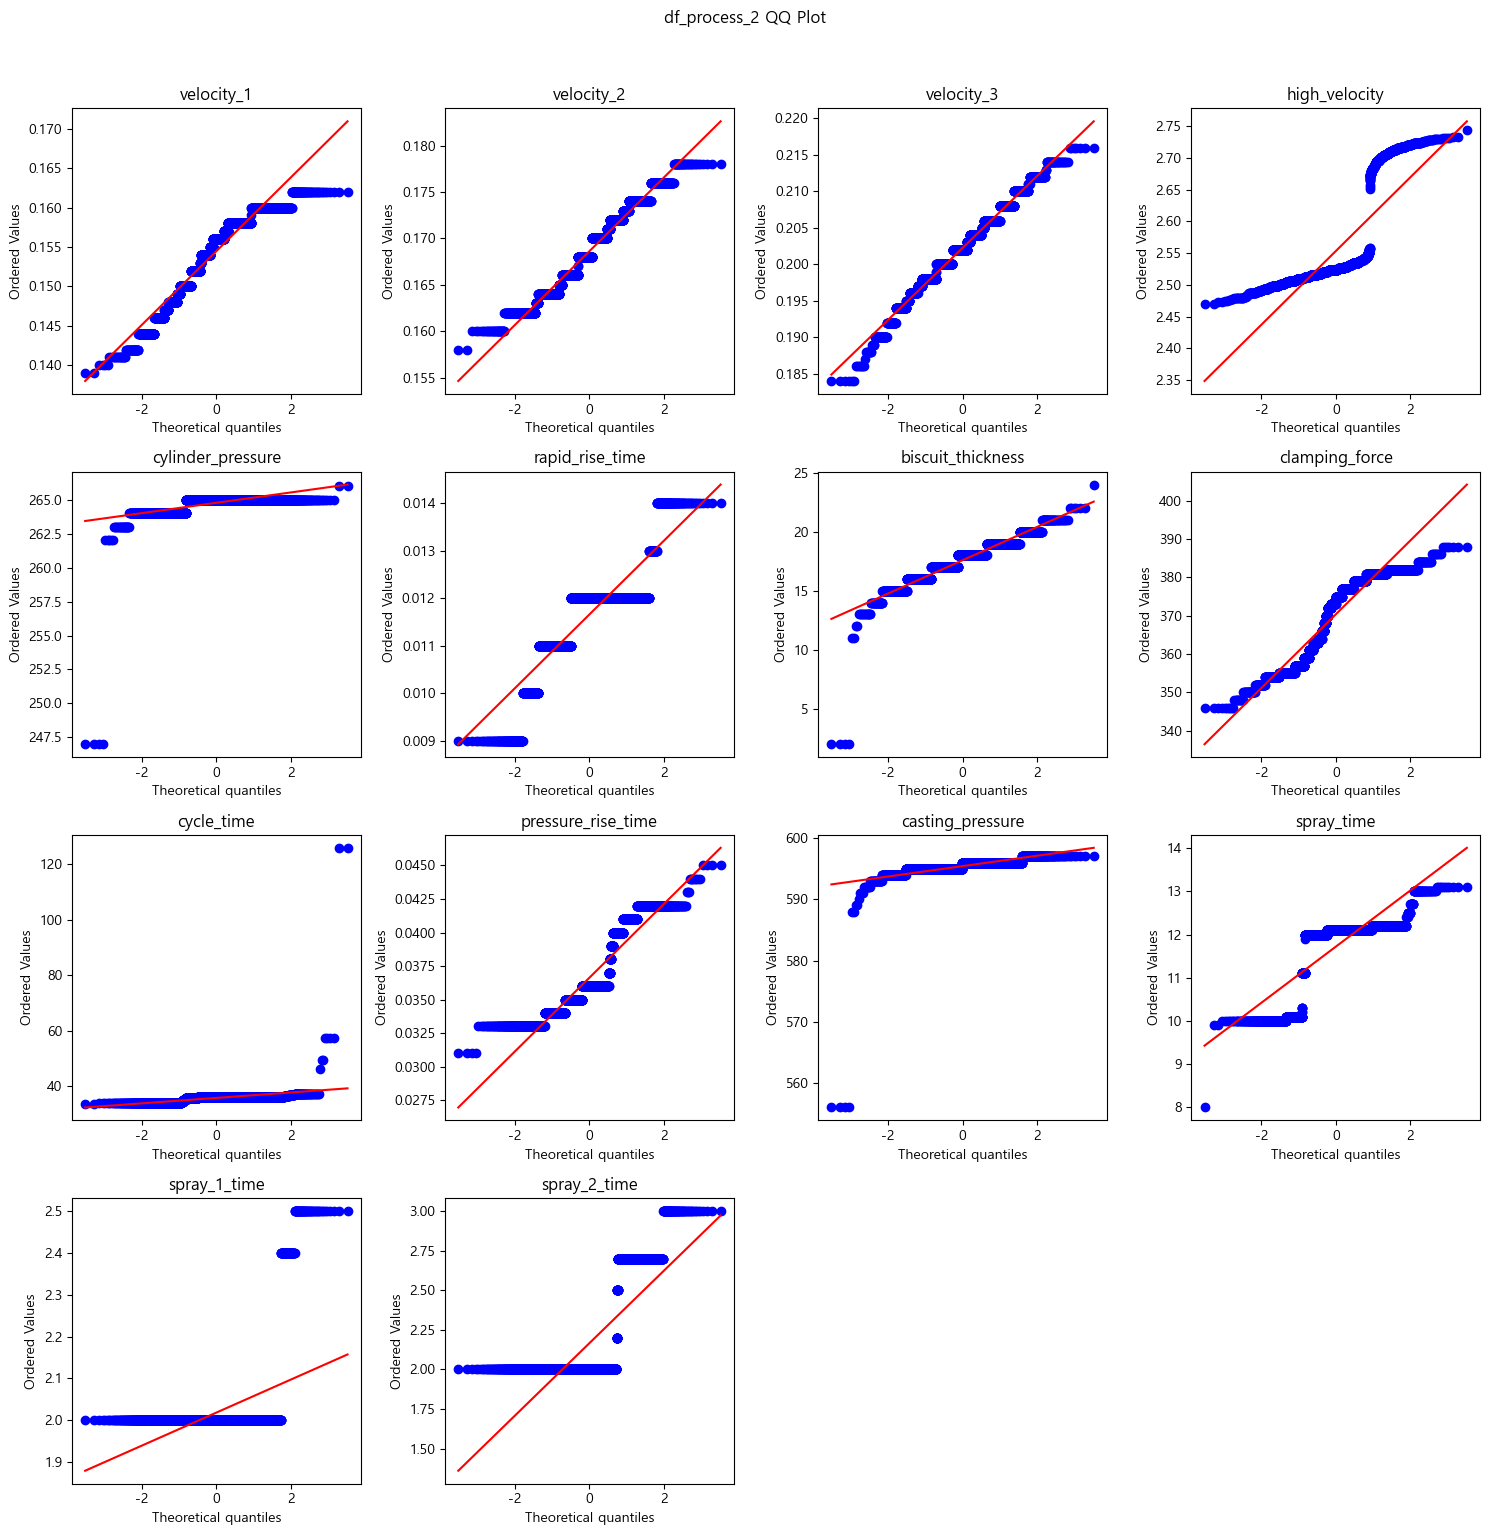

In [13]:
plot_qq_table(df_process_2, 
            title="df_process_2 QQ Plot")

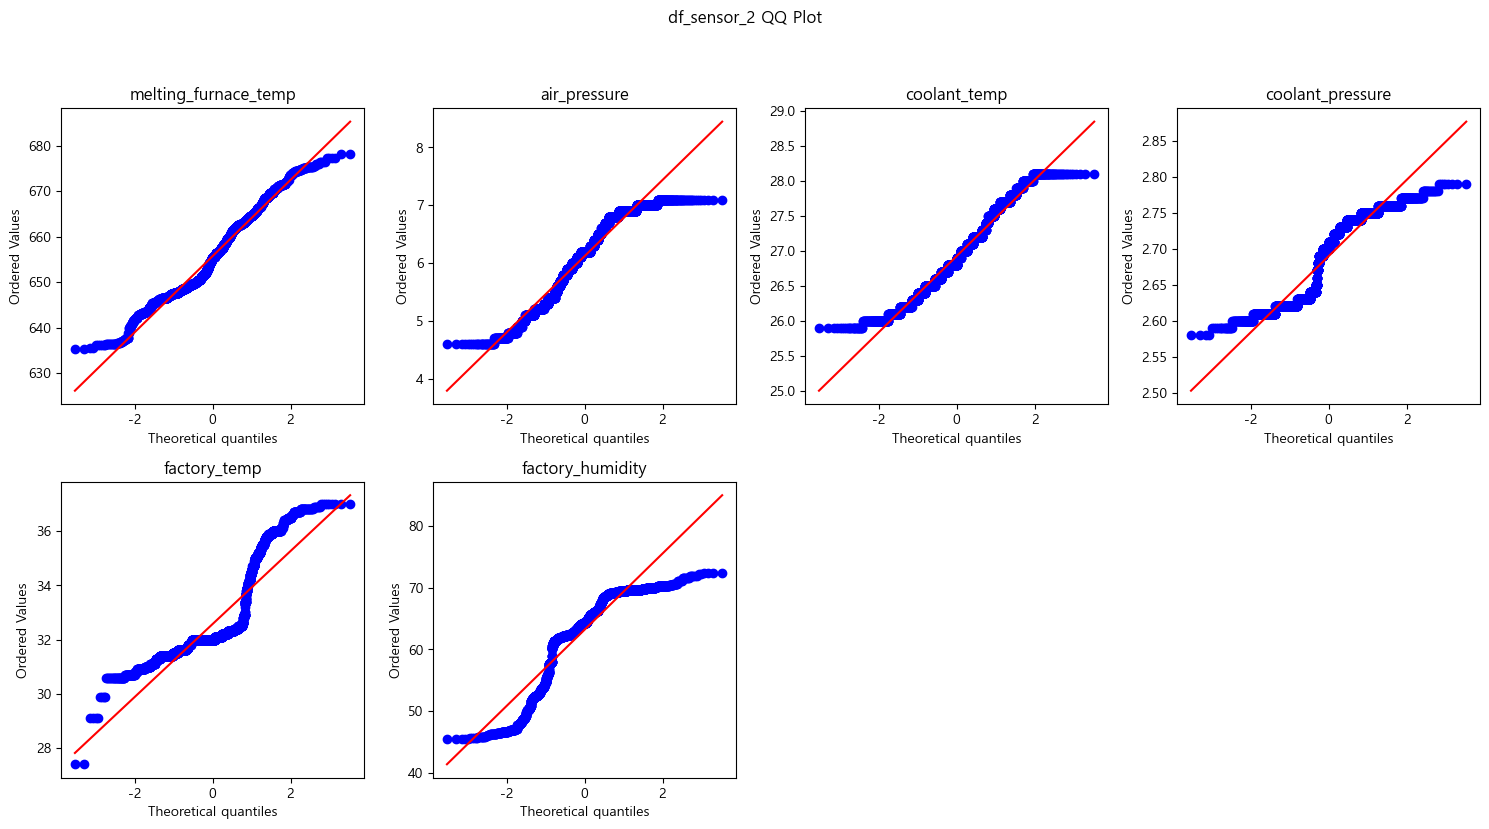

In [14]:
plot_qq_table(df_sensor_2, 
            title="df_sensor_2 QQ Plot")

#### 3.3 Levene 검증

In [15]:
from scipy.stats import levene

# 등분산성 검정 (Levene test)
def create_levene_summary(features_df, defects_df, target_col, df_name, exclude_cols=None, alpha=0.05):
    """등분산성 검정 (Levene test)"""
    print(f"\n{'='*80}")
    print(f"{df_name} 등분산성 검정 (Levene test) - 기준: {target_col}")
    print(f"{'='*80}\n")
    
    # exclude_cols에 속한 컬럼 제외
    df_copied = features_df.copy()
    if exclude_cols:
        df_copied = df_copied.drop(columns=exclude_cols, errors='ignore')

        
    # 숫자형 컬럼만 선택
    df_copied = df_copied.select_dtypes(include='number')    
    
    # 타깃 (index 맞춤)
    target_series = defects_df[target_col]

    # 출력값 저장
    result_list = []
    
    # 각 컬럼별 등분산성 검정
    for col in df_copied.columns:
        group_0 = df_copied[target_series == 0][col].dropna()
        group_1 = df_copied[target_series == 1][col].dropna()
    
        # 등분산성 검정: levene
        stat, p_value = levene(group_0, group_1)

        # H0: 두 그룹의 분산이 같다 (등분산)
        # H1: 두 그룹의 분산이 다르다 (이분산)
        if p_value > alpha:
            result = "등분산 가정 가능"
        else:
            result = "등분산 가정 불가"

        # 출력 값
        result_list.append([
            col, 
            stat, 
            p_value, 
            result
        ]
    )
    
    # 출력화면
    levene_df = pd.DataFrame(
        result_list,
        columns=[
            "변수명", 
            "Levene 통계량", 
            "p-value", 
            "판정"
        ]
    ).set_index("변수명")
    
    display(levene_df)
    
    return levene_df

In [16]:
process_levene_surface = create_levene_summary(
    df_process_2,
    df_defects_2_1,
    "is_defect",
    "df_process_2",
    exclude_cols=['shot_key']
)


df_process_2 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
velocity_1,4.480292,3.436193e-02,등분산 가정 불가
velocity_2,0.730217,3.928743e-01,등분산 가정 가능
velocity_3,1.830792,1.761259e-01,등분산 가정 가능
high_velocity,188.751329,8.084364e-42,등분산 가정 불가
cylinder_pressure,5.546086,1.857985e-02,등분산 가정 불가
rapid_rise_time,0.714535,3.980031e-01,등분산 가정 가능
biscuit_thickness,0.580366,4.462228e-01,등분산 가정 가능
clamping_force,163.045258,1.734345e-36,등분산 가정 불가
cycle_time,15.444339,8.669984e-05,등분산 가정 불가


In [17]:
process_levene_surface = create_levene_summary(
    df_sensor_2,
    df_defects_2_1,
    "is_defect",
    "df_sensor_2",
)


df_sensor_2 등분산성 검정 (Levene test) - 기준: is_defect



,Levene 통계량,p-value,판정
변수명,,,
melting_furnace_temp,19.173745,1.230211e-05,등분산 가정 불가
air_pressure,24.267707,8.792250e-07,등분산 가정 불가
coolant_temp,3.906079,4.819422e-02,등분산 가정 불가
coolant_pressure,7.258745,7.091103e-03,등분산 가정 불가
factory_temp,108.956851,4.036253e-25,등분산 가정 불가
factory_humidity,176.767310,2.442028e-39,등분산 가정 불가


#### 3.4 상관계수 히트맵

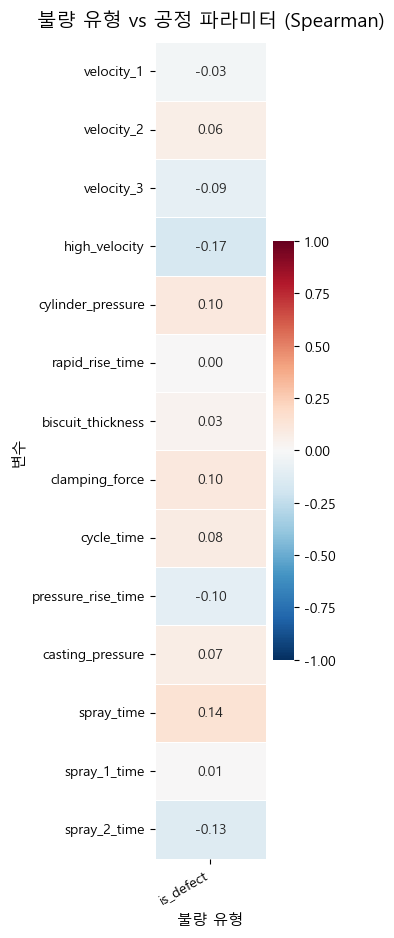

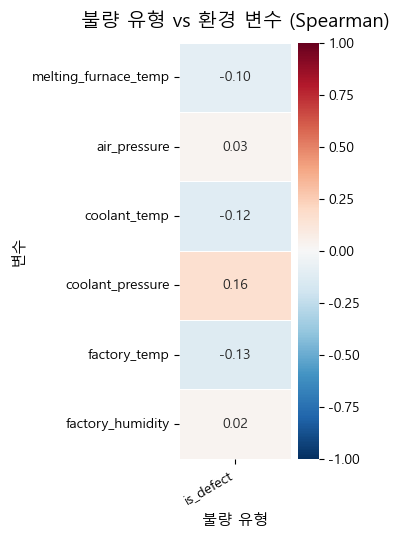

In [18]:
#DEFECT_COLS = [
#    'surface_defect',
#    'structural_defect',
#    'contamination_defect'
#]

DE = ['is_defect']

PROCESS_COLS = [
    'velocity_1', 'velocity_2', 'velocity_3', 'high_velocity',
    'cylinder_pressure', 'rapid_rise_time', 'biscuit_thickness',
    'clamping_force', 'cycle_time', 'pressure_rise_time',
    'casting_pressure', 'spray_time', 'spray_1_time', 'spray_2_time',
]

SENSOR_COLS = [
    'melting_furnace_temp', 'air_pressure', 'coolant_temp', 'coolant_pressure',
    'factory_temp', 'factory_humidity'
]

# 함수
def plot_corr_heatmap(df, defect_cols, feature_cols, title):
    corr = df[defect_cols + feature_cols].corr(method='spearman')
    corr_target = corr.loc[feature_cols, defect_cols]

    fig, ax = plt.subplots(
        figsize=(len(defect_cols) * 1.8, len(feature_cols) * 0.65 + 1.5)
    )

    sns.heatmap(
        corr_target,
        annot=True,
        fmt='.2f',
        cmap='RdBu_r',
        center=0,
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel('불량 유형', fontsize=11)
    ax.set_ylabel('변수', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

# 출력
plot_corr_heatmap(df_original_2_1, DE, PROCESS_COLS, '불량 유형 vs 공정 파라미터 (Spearman)')
plot_corr_heatmap(df_original_2_1, DE, SENSOR_COLS, '불량 유형 vs 환경 변수 (Spearman)')

#### 3.5 샘플 수 & 불량률 비교

In [19]:
# 1. 샘플 수 & 불량률
total    = len(df_original_2_1)
n_defect = df_original_2_1["is_defect"].sum() # 불량제품
n_normal = total - n_defect # 정상 제품
rate     = n_defect / total * 100

print(f"\n=== 기초 현황 ===")
print(f"전체 샘플 : {total:,}개")
print(f"불량      : {int(n_defect):,}개")
print(f"정상      : {int(n_normal):,}개")
print(f"불량률    : {rate:.2f}%")

# 2. 결측치 확인
print("\n=== 결측치 ===")
print(df_original_2_1.isnull().sum())


=== 기초 현황 ===
전체 샘플 : 3,328개
불량      : 946개
정상      : 2,382개
불량률    : 28.43%

=== 결측치 ===
shot_key                0
velocity_1              0
velocity_2              0
velocity_3              0
high_velocity           0
cylinder_pressure       0
rapid_rise_time         0
biscuit_thickness       0
clamping_force          0
cycle_time              0
pressure_rise_time      0
casting_pressure        0
spray_time              0
spray_1_time            0
spray_2_time            0
melting_furnace_temp    0
air_pressure            0
coolant_temp            0
coolant_pressure        0
factory_temp            0
factory_humidity        0
is_defect               0
dtype: int64


#### 3.6 박스플롯

In [20]:
# 박스플롯 함수
import math

def plot_boxplots(df, cols, group_title):
    
    # is_defect를 문자열로 변환
    df_a = df.copy()
    df_a["is_defect"] = df["is_defect"].map({0: "정상", 1: "불량"})
    
    n_rows = math.ceil(len(cols) / 4)  # 올림 나눗셈

    fig, axes = plt.subplots(n_rows, 4, figsize=(20, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cols):
        sns.boxplot(
            x="is_defect", y=col,
            data=df_a,
            palette={"정상": "#4C72B0", "불량": "#DD8452"},
            ax=axes[i]
        )
        axes[i].set_title(col, fontsize=11, fontweight="bold")
        axes[i].set_xlabel("")
        axes[i].set_xticklabels(["정상", "불량"], fontsize=10)

    # 빈 subplot 숨기기
    for j in range(len(cols), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"[{group_title}] 정상 vs 불량 분포 비교", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()
    
    return df_a

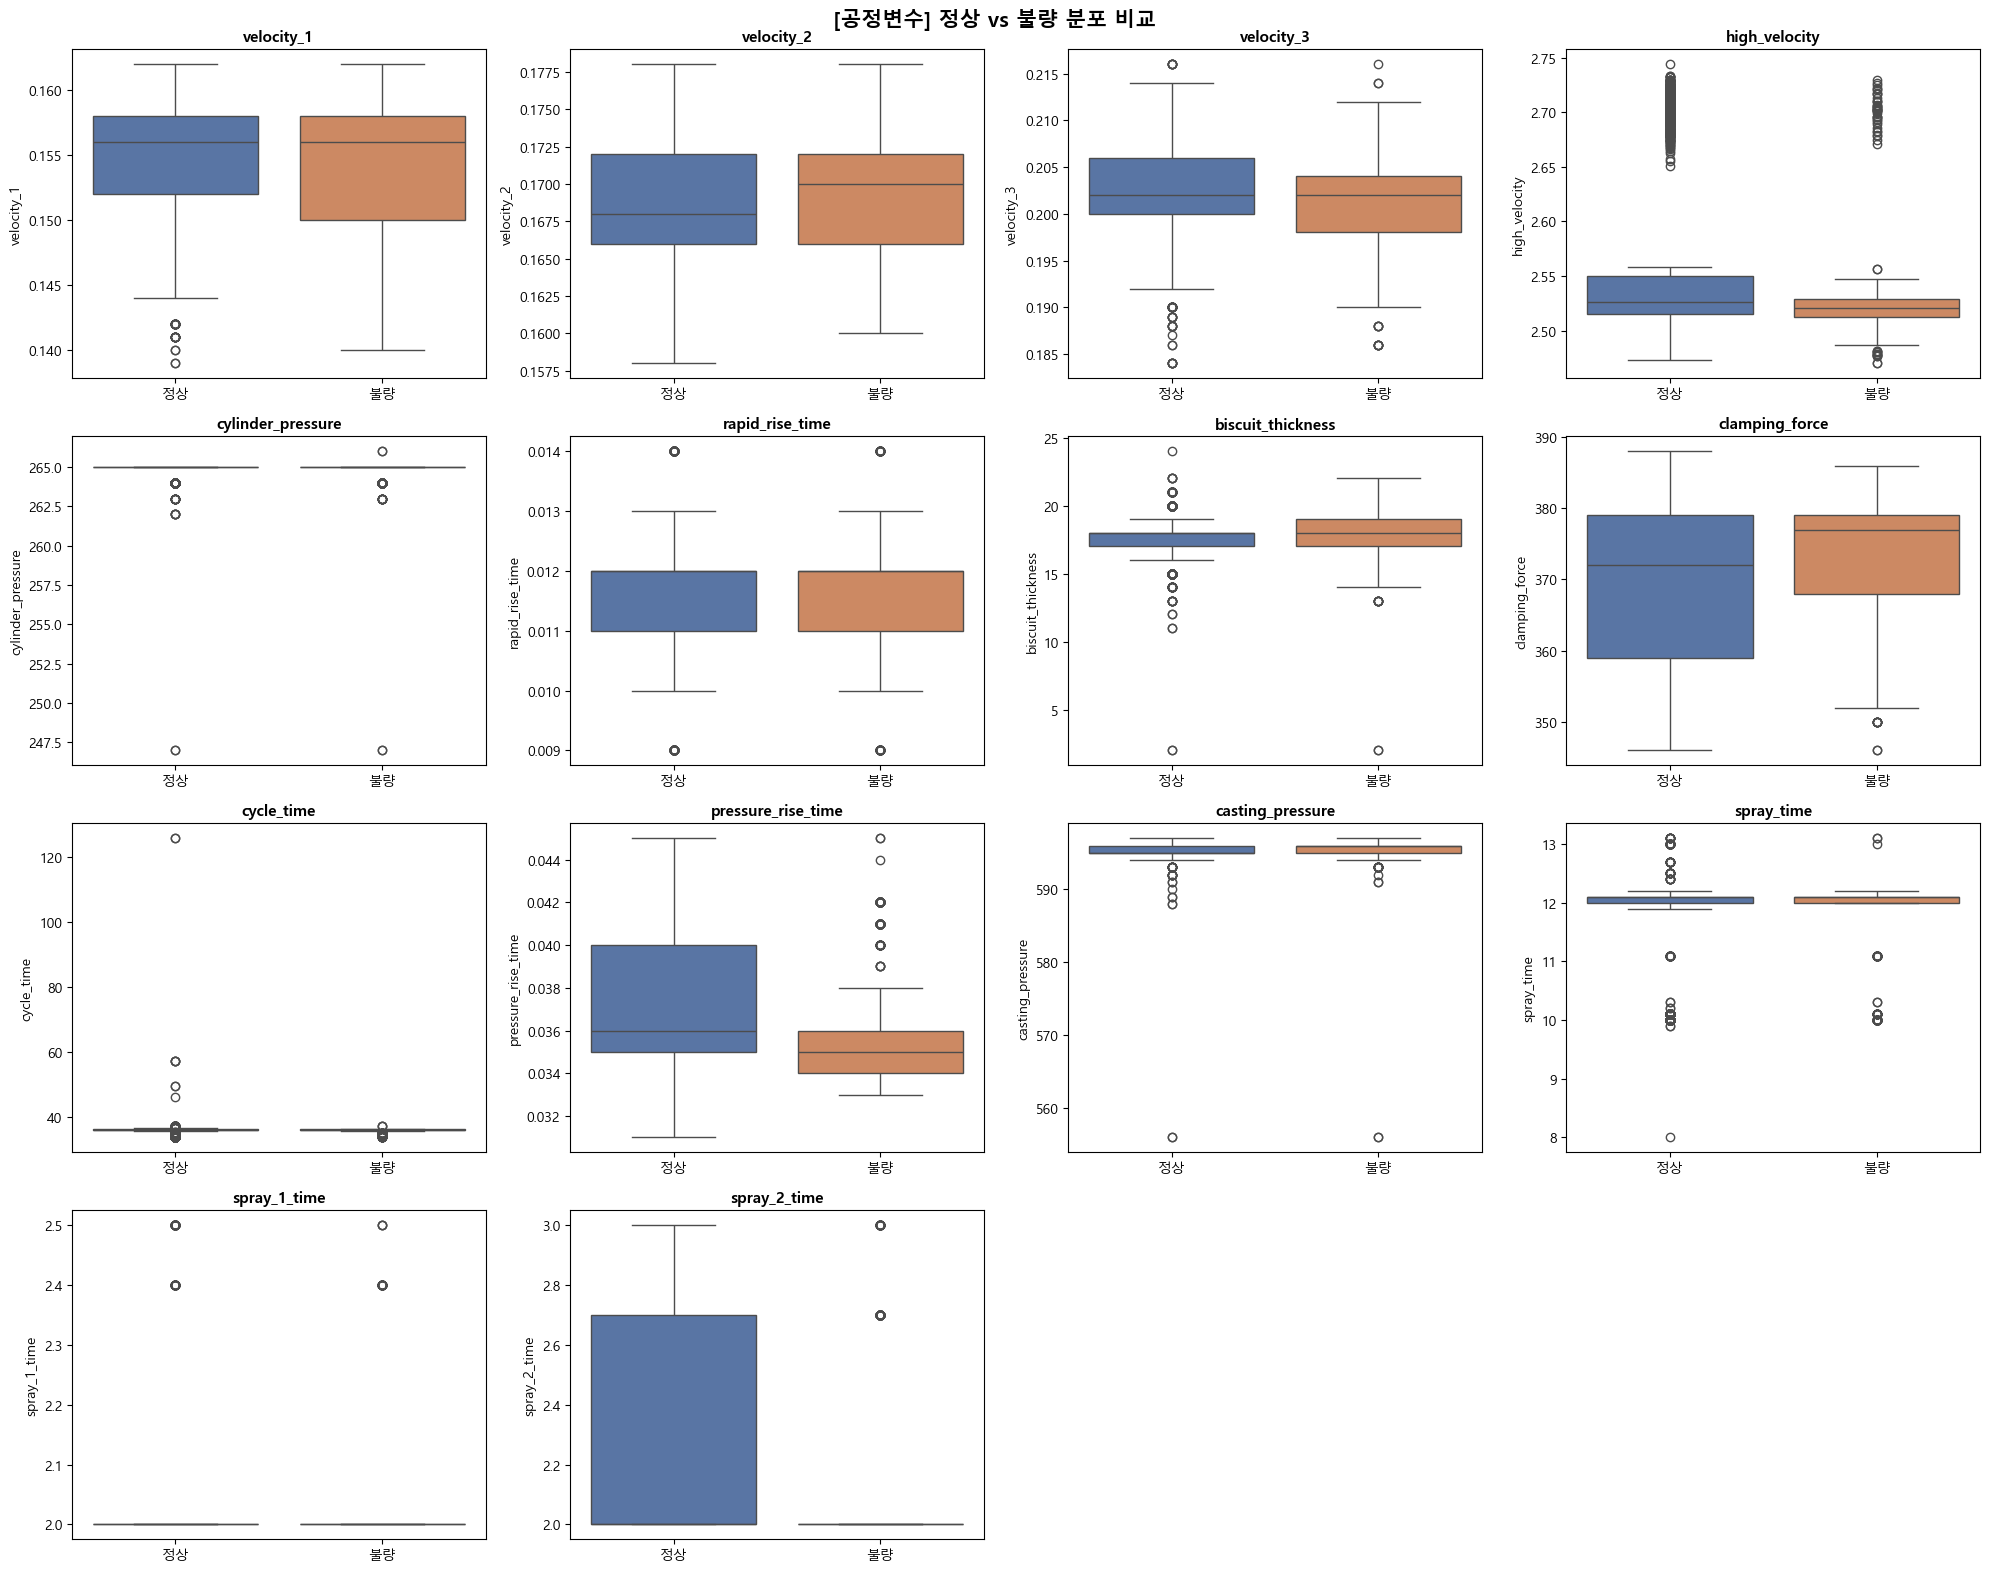

In [21]:
# process 관련 변수의 박스플롯
boxplot_of_process_1 = plot_boxplots(df_original_2_1, PROCESS_COLS, "공정변수")

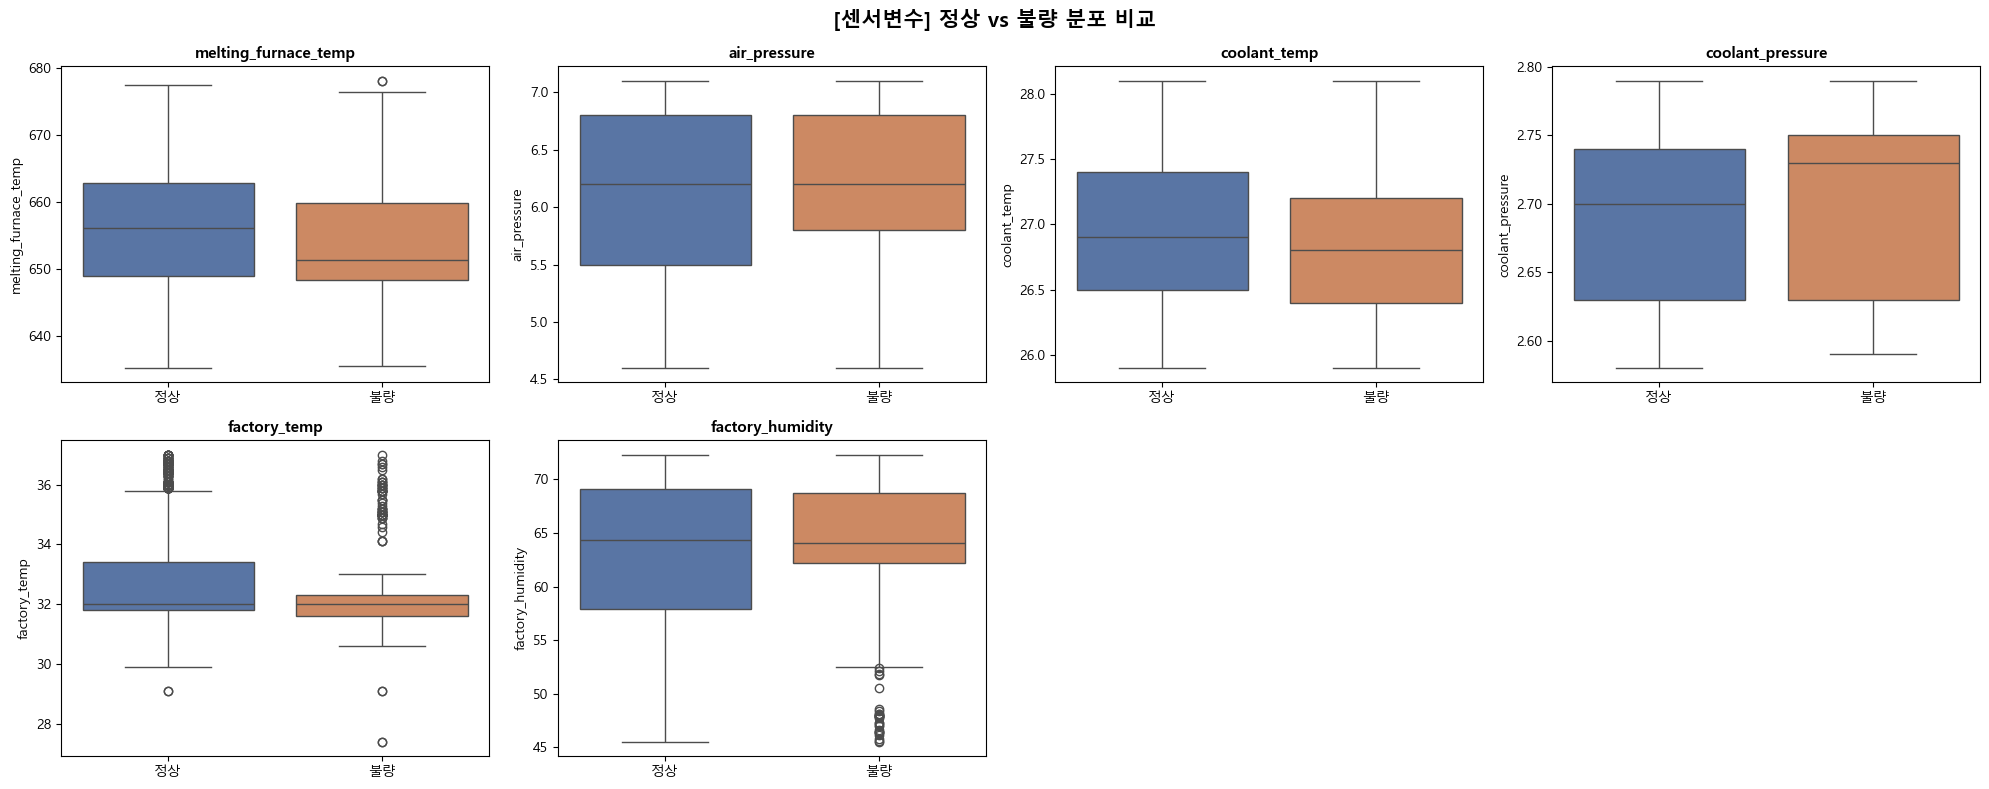

In [22]:
boxplot_of_sensor_1 = plot_boxplots(df_original_2_1, SENSOR_COLS, "센서변수")

- 박스플롯을 본 이유는 정상일 때와 불량일 때, 각각의 변수의 분포가 어떤지 궁금해서 확인해본 것
- 분포가 너무 많이 다르면 불량에 영향을 줬을지도 모르니까
- 분포가 완전히 다르게 형성된다면 그것도 그거 나름대로 의미가 있을수도 있지 않을까 싶어서
- 만약에 분포가 비슷하다면 어떤 이상치가 많은지도 궁금해서

### 4. welch-t 검정

In [23]:
def interpret_cohens_d(d):
    if d < 0.1:   
        return "매우 작음"
    elif d < 0.3: 
        return "작음"
    elif d < 0.5:
        return "중간"
    else:         
        return "큼"

In [24]:
# Welch's t-test

ALL_COLS = PROCESS_COLS + SENSOR_COLS

result = []

alpha = 0.05

for col in ALL_COLS:
    g0 = df_original_2_1.loc[df_original_2_1["is_defect"] == 0, col]
    g1 = df_original_2_1.loc[df_original_2_1["is_defect"] == 1, col]
    
    t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)
    
    # Cohen's d
    pooled_std = np.sqrt((g0.std()**2 + g1.std()**2) / 2)
    cohens_d   = (g1.mean() - g0.mean()) / pooled_std
    
    result.append({
        "요인":       col,
        "정상 제품의 평균": round(g0.mean(), 4),
        "불량 제품의 평균": round(g1.mean(), 4),
        "t-통계량": round(t_stat, 4),
        "Cohen's d": round(cohens_d, 4),
        "효과크기 해석": interpret_cohens_d(abs(cohens_d)),
        "p-value": float(f"{p_val:.4e}"),
    })

df_welchs = pd.DataFrame(result)

df_welchs['통계적 유의성 여부'] = df_welchs['p-value'] < alpha

display(df_welchs)

,요인,정상 제품의 평균,불량 제품의 평균,t-통계량,Cohen's d,효과크기 해석,p-value,통계적 유의성 여부
0,velocity_1,0.1546,0.1542,1.8618,-0.0720,매우 작음,6.280600e-02,False
1,velocity_2,0.1685,0.1690,-3.5163,0.1354,작음,4.489700e-04,True
2,velocity_3,0.2025,0.2015,5.4836,-0.2092,작음,4.760000e-08,True
3,high_velocity,2.5635,2.5274,17.5537,-0.5792,큼,6.444600e-66,True
4,cylinder_pressure,264.7435,264.8161,-2.2210,0.0902,매우 작음,2.651400e-02,True
5,rapid_rise_time,0.0117,0.0117,0.2435,-0.0095,매우 작음,8.076300e-01,False
6,biscuit_thickness,17.5735,17.6290,-0.9398,0.0366,매우 작음,3.474500e-01,False
7,clamping_force,369.4353,372.6268,-8.9336,0.3295,중간,8.894600e-19,True
8,cycle_time,35.6840,35.7574,-1.1513,0.0345,매우 작음,2.497200e-01,False
9,pressure_rise_time,0.0368,0.0362,4.9924,-0.1916,작음,6.559500e-07,True


### 5. Mann-Whitney U 검정

In [25]:
def interpret_rbc(r):
    if r < 0.1:   
        return "매우 작음"
    elif r < 0.3: 
        return "작음"
    elif r < 0.5: 
        return "중간"
    else:         
        return "큼"

In [26]:
# Mann-Whitney U
result_mwu = []
for col in ALL_COLS:
    g0 = df_original_2_1.loc[df_original_2_1["is_defect"] == 0, col]
    g1 = df_original_2_1.loc[df_original_2_1["is_defect"] == 1, col]
    
    u_stat, p_val = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    
    # Rank-biserial correlation (효과 크기)
    r_rbc = 1 - (2 * u_stat) / (len(g0) * len(g1))
    
    result_mwu.append({
        "요인":            col,
        "U-통계량":        round(u_stat, 4),
        "rank-biserial r": round(r_rbc, 4),
        "효과크기 해석": interpret_rbc(abs(r_rbc)),
        "p-value":         float(f"{p_val:.4e}"),
    })

df_mwu = pd.DataFrame(result_mwu)

df_mwu["통계적 유의성 여부"] = df_mwu["p-value"] < alpha

display(df_mwu)

,요인,U-통계량,rank-biserial r,효과크기 해석,p-value,통계적 유의성 여부
0,velocity_1,1170851.5,-0.0392,매우 작음,7.495100e-02,False
1,velocity_2,1036119.5,0.0804,매우 작음,2.636200e-04,True
2,velocity_3,1258631.0,-0.1171,작음,1.099600e-07,True
3,high_velocity,1370848.0,-0.2167,작음,1.543600e-22,True
4,cylinder_pressure,1021614.0,0.0933,매우 작음,2.220200e-09,True
5,rapid_rise_time,1122143.5,0.0040,매우 작음,8.314500e-01,False
6,biscuit_thickness,1078991.5,0.0423,매우 작음,5.027400e-02,False
7,clamping_force,980118.5,0.1301,작음,4.069000e-09,True
8,cycle_time,1015785.5,0.0984,매우 작음,6.478400e-06,True
9,pressure_rise_time,1263975.5,-0.1219,작음,2.404100e-08,True


In [27]:
# 정렬할 때는 절댓값 기준으로 나열
df_mwu.sort_values('rank-biserial r', key=abs, ascending=False)

,요인,U-통계량,rank-biserial r,효과크기 해석,p-value,통계적 유의성 여부
3,high_velocity,1370848.0,-0.2167,작음,1.543600e-22,True
17,coolant_pressure,900887.0,0.2004,작음,1.243300e-19,True
11,spray_time,932253.0,0.1726,작음,3.613800e-16,True
18,factory_temp,1307176.0,-0.1602,작음,3.719000e-13,True
16,coolant_temp,1295997.0,-0.1503,작음,1.172300e-11,True
7,clamping_force,980118.5,0.1301,작음,4.069000e-09,True
14,melting_furnace_temp,1271224.0,-0.1283,작음,7.423800e-09,True
9,pressure_rise_time,1263975.5,-0.1219,작음,2.404100e-08,True
13,spray_2_time,1263299.0,-0.1213,작음,1.135500e-13,True
2,velocity_3,1258631.0,-0.1171,작음,1.099600e-07,True


---
---
#### 효과크기 해석을 기준으로 정렬

In [28]:
def sort_by_category(df, col, order, ascending=True):
    return df.sort_values(
        col,
        key=lambda x: x.map({v: i for i, v in enumerate(order)}),
        ascending=ascending
    )
    
    
order = ['큼', '중간', '작음', '매우 작음']

print("welch's T-test 결과")
sort_by_category(df_welchs, "효과크기 해석", order)

welch's T-test 결과


,요인,정상 제품의 평균,불량 제품의 평균,t-통계량,Cohen's d,효과크기 해석,p-value,통계적 유의성 여부
3,high_velocity,2.5635,2.5274,17.5537,-0.5792,큼,6.444600e-66,True
7,clamping_force,369.4353,372.6268,-8.9336,0.3295,중간,8.894600e-19,True
18,factory_temp,32.7593,32.0994,13.7156,-0.4789,중간,2.104800e-41,True
17,coolant_pressure,2.6847,2.7024,-8.1755,0.3161,중간,5.711400e-16,True
13,spray_2_time,2.1890,2.1097,7.1379,-0.2664,작음,1.327700e-12,True
14,melting_furnace_temp,656.1887,654.4836,5.4176,-0.2048,작음,6.823900e-08,True
2,velocity_3,0.2025,0.2015,5.4836,-0.2092,작음,4.760000e-08,True
1,velocity_2,0.1685,0.1690,-3.5163,0.1354,작음,4.489700e-04,True
19,factory_humidity,62.7054,64.4129,-8.1484,0.2824,작음,5.567800e-16,True
16,coolant_temp,26.9639,26.8212,6.8066,-0.2610,작음,1.367600e-11,True


In [29]:
order = ['큼', '중간', '작음', '매우 작음']

print("MWU 결과")
sort_by_category(df_mwu, "효과크기 해석", order)

MWU 결과


,요인,U-통계량,rank-biserial r,효과크기 해석,p-value,통계적 유의성 여부
3,high_velocity,1370848.0,-0.2167,작음,1.543600e-22,True
2,velocity_3,1258631.0,-0.1171,작음,1.099600e-07,True
7,clamping_force,980118.5,0.1301,작음,4.069000e-09,True
9,pressure_rise_time,1263975.5,-0.1219,작음,2.404100e-08,True
13,spray_2_time,1263299.0,-0.1213,작음,1.135500e-13,True
14,melting_furnace_temp,1271224.0,-0.1283,작음,7.423800e-09,True
11,spray_time,932253.0,0.1726,작음,3.613800e-16,True
16,coolant_temp,1295997.0,-0.1503,작음,1.172300e-11,True
17,coolant_pressure,900887.0,0.2004,작음,1.243300e-19,True
18,factory_temp,1307176.0,-0.1602,작음,3.719000e-13,True
